# Кластеризация пользовательских запросов с эмбеддингами

**Практика** Мы найдём темы в русских запросах голосового ассистента: сначала разберём идею, затем построим воспроизводимый baseline `эмбеддер → UMAP → HDBSCAN`, проанализируем кластеры и сформируем `submission.csv`.

Данные уже лежат рядом с ноутбуком, поэтому выборка не зависит от сети. При первом запуске `sentence-transformers` скачает веса модели; дальше всё работает локально на CPU.



## 1. Что именно мы делаем

**Эмбеддинг** — числовой вектор текста. Хороший энкодер помещает близкие по смыслу запросы рядом, даже если слова различаются. Например, «поставь будильник на семь» и «разбуди меня в 7 утра» должны быть ближе друг к другу, чем к «включи новости».

Для L2-нормированных векторов косинусная близость — это их скалярное произведение:

$$\operatorname{cosine}(x,y)=\frac{x\cdot y}{\lVert x\rVert\lVert y\rVert},\qquad \lVert x\rVert=\lVert y\rVert=1.$$

**Классификация** получает заранее известные классы и учится назначать один из них. **Кластеризация** получает только тексты и сама группирует похожие объекты; часть объектов может остаться шумом (`-1`). Поэтому название кластера не имеет смысла само по себе — важен состав группы.

TF–IDF сравнивает в основном совпадения слов и n-грамм. Он полезен как быстрый базовый метод, но вообще перестает связывать перефразировки («проложи маршрут» / «как добраться») и может переоценить общие служебные слова.


In [2]:
import numpy as np

# Игрушечные векторы: первые две фразы направлены почти одинаково.
toy_queries = [
    "поставь будильник на семь",
    "разбуди меня в 7 утра",
    "какая погода завтра",
]
toy_vectors = np.array([[0.98, 0.20], [0.94, 0.34], [-0.15, 0.99]])
toy_vectors = toy_vectors / np.linalg.norm(toy_vectors, axis=1, keepdims=True)
similarity = toy_vectors @ toy_vectors.T
print(toy_queries)
np.round(similarity, 2)


['поставь будильник на семь', 'разбуди меня в 7 утра', 'какая погода завтра']


array([[1.  , 0.99, 0.05],
       [0.99, 1.  , 0.2 ],
       [0.05, 0.2 , 1.  ]])

В реальности мы не задаём координаты руками: их строит предобученный энкодер. Но логика та же: высокая косинусная близость означает кандидатуру в одну тему, а не гарантированно один и тот же интент.

Ниже используется русская фиксированная стратифицированная выборка MASSIVE: в каждом из 60 интентов — по 2 обучающих, валдиационных и финальных тестовых запроса. Редкие интенты в исходных разбиениях MASSIVE не встречаются во всех трёх частях, поэтому учебные train/validation/evaluation сделаны как детерминированное непересекающееся разбиение общей русской части. `evaluation_labels.csv` — открытый локальный эталон для проверки упражнения; модель в бейзлайне не читает его.


In [10]:
pip install sentence-transformers

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 488 kB 1.4 MB/s eta 0:00:01
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import random

import hdbscan
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import umap.umap_ as umap
from sentence_transformers import SentenceTransformer
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, v_measure_score

SEED = 20260807
np.random.seed(SEED)
random.seed(SEED)
sns.set_theme(style="whitegrid")

DATA_DIR = Path("data")
train = pd.read_csv(DATA_DIR / "train_labeled.csv")
validation = pd.read_csv(DATA_DIR / "validation_labeled.csv", dtype={"query_id": str})
evaluation = pd.read_csv(DATA_DIR / "evaluation_queries.csv", dtype={"query_id": str})

print(f"train: {train.shape}; validation: {validation.shape}; evaluation: {evaluation.shape}")
print(f"интентов в train: {train['intent'].nunique()}")
train.head()


train: (120, 2); validation: (120, 3); evaluation: (120, 2)
интентов в train: 60


,text,intent
0,каков долларовый эквивалент в песо,qa_currency
1,привет яндекс эта песня слишком шумная,music_dislikeness
2,сегодня,iot_coffee
3,купи мне билет на пять вечера в гатчину,transport_ticket
4,нужно ли подключать робот-пылесос к розетке,iot_cleaning


## 2. Базовый эмбеддер

Берём `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2`. Это готовый многоязычный sentence encoder. Явно нормализуем выходные векторы: тогда косинусная близость равна скалярному произведению и масштаб векторов не влияет на расстояния.


In [7]:
from huggingface_hub.utils import enable_progress_bars
from transformers.utils import logging

enable_progress_bars()
logging.set_verbosity_info()

MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
model = SentenceTransformer(MODEL_NAME, device="cpu")

def encode_normalized(texts):
    vectors = model.encode(
        texts.tolist() if hasattr(texts, "tolist") else texts,
        batch_size=32,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=False,
    ).astype("float32")
    norms = np.linalg.norm(vectors, axis=1, keepdims=True)
    return vectors / np.clip(norms, 1e-12, None)

validation_embeddings = encode_normalized(validation["text"])
evaluation_embeddings = encode_normalized(evaluation["text"])
print(validation_embeddings.shape, np.linalg.norm(validation_embeddings, axis=1).min())


loading configuration file config.json from cache at /Users/romanfilonov/.cache/huggingface/hub/models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2/snapshots/e8f8c211226b894fcb81acc59f3b34ba3efd5f42/config.json
Model config BertConfig {
  "architectures": [
    "BertModel"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 1536,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "transformers_version": "4.57.6",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 250037
}

loading weights file model.safetensors from cache at /Users/romanfilonov/.cache/huggingface/hub/models--sentence-transformers--paraphrase-multilingual-MiniL

(120, 384) 0.9999999


## 3. UMAP + HDBSCAN

UMAP сжимает исходное пространство эмбеддингов, сохраняя локальные соседства. Здесь 10-мерное сжатие подаётся в HDBSCAN; отдельно мы сделаем 2D-проекцию для картинки. HDBSCAN умеет оставлять неопределённые точки шумом и не требует заранее назвать число кластеров.



In [8]:
def cluster_with_umap(embeddings, n_neighbors, min_cluster_size, min_samples):
    n_samples = len(embeddings)

    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=min(n_neighbors, n_samples - 1),
        min_dist=0.0,
        metric="cosine",
        random_state=SEED,
    )
    compressed = reducer.fit_transform(embeddings)

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        metric="euclidean",
        cluster_selection_method="eom",
    )
    return clusterer.fit_predict(compressed), compressed

candidates = [
    {"n_neighbors": 10, "min_cluster_size": 2, "min_samples": 1},
    {"n_neighbors": 10, "min_cluster_size": 3, "min_samples": 1},
    {"n_neighbors": 15, "min_cluster_size": 2, "min_samples": 1},
    {"n_neighbors": 15, "min_cluster_size": 4, "min_samples": 1},
    {"n_neighbors": 20, "min_cluster_size": 3, "min_samples": 2},
]
rows = []
for params in candidates:
    labels, _ = cluster_with_umap(validation_embeddings, **params)
    rows.append({
        **params,
        "ARI": adjusted_rand_score(validation["intent"], labels),
        "NMI": normalized_mutual_info_score(validation["intent"], labels),
        "V-measure": v_measure_score(validation["intent"], labels),
        "clusters": len(set(labels)) - int(-1 in labels),
        "noise_share": (labels == -1).mean(),
    })
search = pd.DataFrame(rows).sort_values(["ARI", "NMI"], ascending=False).reset_index(drop=True)
search.round(3)


/Users/romanfilonov/Library/Python/3.9/lib/python/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/romanfilonov/Library/Python/3.9/lib/python/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/romanfilonov/Library/Python/3.9/lib/python/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/romanfilonov/Library/Python/3.9/lib/python/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/romanfilonov/Library/Python/3.9/lib/python/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,n_neighbors,min_cluster_size,min_samples,ARI,NMI,V-measure,clusters,noise_share
0,15,2,1,0.159,0.803,0.803,36,0.075
1,10,3,1,0.121,0.732,0.732,20,0.092
2,10,2,1,0.114,0.770,0.770,31,0.133
3,15,4,1,0.113,0.703,0.703,15,0.050
4,20,3,2,0.101,0.679,0.679,13,0.100


In [9]:
best = search.iloc[0]
best_params = {key: int(best[key]) for key in ["n_neighbors", "min_cluster_size", "min_samples"]}
evaluation_labels, evaluation_compressed = cluster_with_umap(evaluation_embeddings, **best_params)
print("Параметры baseline:", best_params)
print("Кластеров без шума:", len(set(evaluation_labels)) - int(-1 in evaluation_labels))
print("Доля шума:", f"{(evaluation_labels == -1).mean():.1%}")


Параметры baseline: {'n_neighbors': 15, 'min_cluster_size': 2, 'min_samples': 1}
Кластеров без шума: 34
Доля шума: 16.7%


/Users/romanfilonov/Library/Python/3.9/lib/python/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Важно: UMAP полезен для сжатия и визуализации, но 2D-карта неизбежно искажает расстояния. Silhouette тоже не заменяет проверку: он не знает истинных интентов, зависит от выбранного пространства и плохо отражает полезность решения при шуме. Если размеченная внешняя выборка есть, оценивайте ARI/NMI/V-measure на ней; в реальном продукте дополните это ручной проверкой тем.


/Users/romanfilonov/Library/Python/3.9/lib/python/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


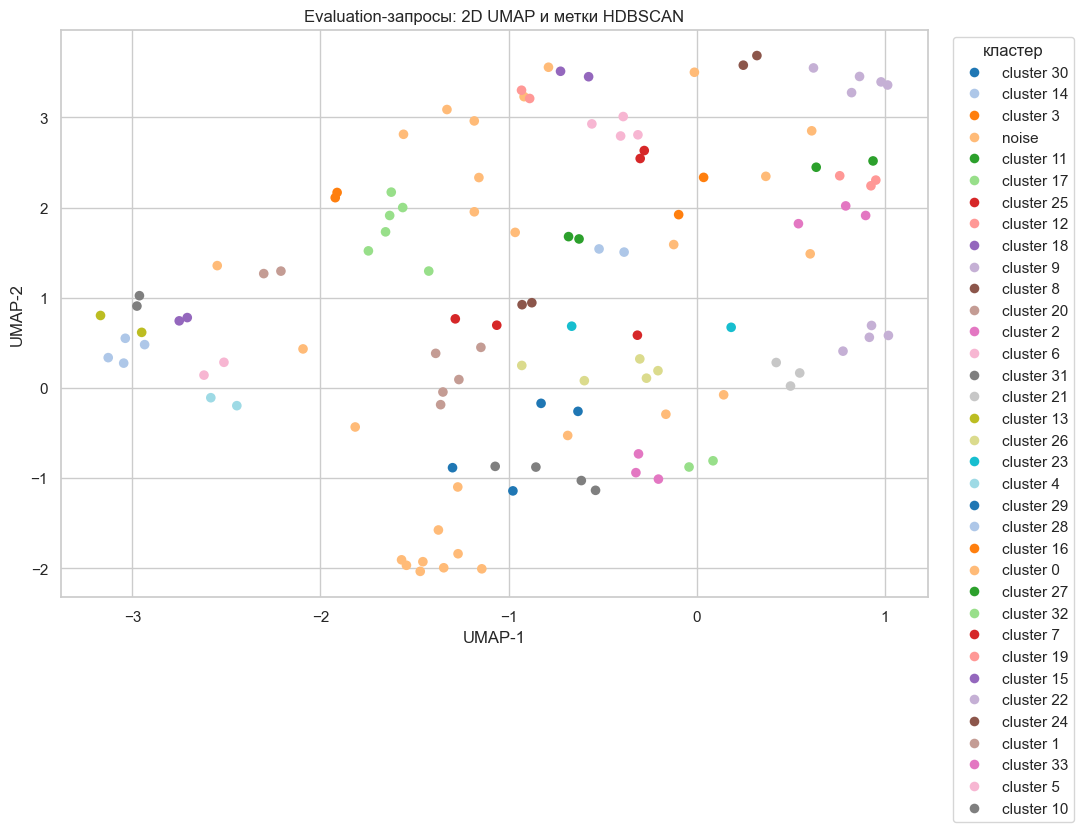

In [10]:
# Эта 2D-проекция — инструмент исследования, не вход HDBSCAN.
plot_reducer = umap.UMAP(
    n_components=2,
    n_neighbors=int(best_params["n_neighbors"]),
    min_dist=0.05,
    metric="cosine",
    random_state=SEED,
)
coordinates = plot_reducer.fit_transform(evaluation_embeddings)
plot_labels = pd.Series(evaluation_labels).map(lambda x: "noise" if x == -1 else f"cluster {x}")

plt.figure(figsize=(11, 8))
sns.scatterplot(x=coordinates[:, 0], y=coordinates[:, 1], hue=plot_labels, palette="tab20", s=48, linewidth=0)
plt.title("Evaluation-запросы: 2D UMAP и метки HDBSCAN")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="кластер")
plt.tight_layout()


## 4. Разбор результата

Размер не равен качеству: маленький плотный кластер может быть ценной темой, а большой — смешивать соседние интенты. Для быстрой человеческой проверки показываем представителя: запрос с максимальной cosine similarity к центроиду своего кластера.


In [11]:
result = evaluation.copy()
result["cluster_id"] = evaluation_labels

sizes = result["cluster_id"].value_counts().rename_axis("cluster_id").reset_index(name="size")
display(sizes.sort_values("cluster_id"))

representatives = []
for cluster_id in sorted(set(evaluation_labels)):
    if cluster_id == -1:
        continue
    indices = np.flatnonzero(evaluation_labels == cluster_id)
    centroid = evaluation_embeddings[indices].mean(axis=0)
    centroid /= np.linalg.norm(centroid)
    representative_index = indices[np.argmax(evaluation_embeddings[indices] @ centroid)]
    representatives.append({
        "cluster_id": cluster_id,
        "size": len(indices),
        "representative_query": evaluation.iloc[representative_index]["text"],
    })
representatives_table = pd.DataFrame(representatives, columns=["cluster_id", "size", "representative_query"])
display(representatives_table.sort_values("size", ascending=False))


,cluster_id,size
0,-1,20
1,0,8
17,1,2
13,2,3
33,3,2
27,4,2
15,5,2
7,6,4
20,7,2
30,8,2


,cluster_id,size,representative_query
0,0,8,измени громкость
17,17,6,что приготовить на обед
26,26,5,начать проигрывание опять
9,9,5,забронируйте мне билет на поезд
20,20,5,выключи умную розетку
14,14,4,сделай мне одолжение мои глаза напрягаются из ...
31,31,4,сохранить мнение о песне
6,6,4,сотри мой календарь
22,22,4,сколько стоят акции starbuck's
2,2,3,твитни жалобу в verizon


Типичные ошибки интерпретации:

* соседние смыслы могут слиться: например, запрос погоды и общий вопрос о времени;
* один интент может распасться из-за имён, чисел, редкой формулировки или малого размера группы;
* `-1` не «неправильный кластер», а честная неопределённость модели;
* не называйте кластер по одному представителю — сначала прочитайте несколько его запросов.

В боевой задаче после чтения примеров мы дали бы темам понятные бизнес-названия, но для метрик это не нужно.


## 5. Submission и локальная проверка

Формат строго такой:

```csv
query_id,cluster_id
0001,topic_7
0002,topic_7
0003,-1
```

Имена кластеров произвольны: ARI, NMI и V-measure инвариантны к переименованию. Мы переведём целочисленные метки HDBSCAN в строки `topic_*`, а шум оставим `-1`.


In [12]:
submission = pd.DataFrame({
    "query_id": evaluation["query_id"],
    "cluster_id": ["-1" if label == -1 else f"topic_{label}" for label in evaluation_labels],
})
submission.to_csv("submission.csv", index=False)
submission.head(), submission.shape


(  query_id cluster_id
 0     0001   topic_30
 1     0002   topic_14
 2     0003    topic_3
 3     0004         -1
 4     0005         -1,
 (120, 2))

In [16]:
# Валидатор читает открытый локальный эталон data/evaluation_labels.csv.
# Запускайте из консоли скрипт
# python validate_clustering.py --predictions submission.csv


## Ваша ЗАДАЧА: улучшить эмбеддер

Не меняя разметку, дообучите эмбеддер с помощью любого metric learning подхода **только на `train_labeled.csv`**. Сформируйте положительные пары запросов одного интента и отрицательные пары разных интентов. Затем снова получите эмбеддинги evaluation-запросов, подберите параметры HDBSCAN только на `validation_labeled.csv`, заново создайте `submission.csv` и проверьте его валидатором.

В submission не должно быть исходных `intent`: только `query_id,cluster_id`. Сравните ARI, NMI, V-measure, число кластеров, долю шума и обязательно несколько реальных групп. Готового кода fine-tuning в материалах намеренно нет.
